# 25 - Pocket embedding vs pocket RMSD: how many pairs, and which
# view shows it best

`21_pocket_embedding_vs_pocket_rmsd.ipynb` already restructures
pocket comparison around **same-ligand pocket pairs only** - unlike
notebook 18's molecule comparison, it never compares two different
ligands' pockets, so there is no cross-ligand overrepresentation
problem to fix here. What this notebook adds:

1. **How many pairs are we actually considering?** Total pocket
   pairs, the well-aligned subset, and - per ligand code - how many
   distinct pockets and how many pairs contribute (notebook 21 has no
   structure/pair cap active, so this is the true, uncapped count).
2. **Three visualisation styles side by side** for the cosine-vs-
   RMSD relationship - hexbin (density), scatter (individual pairs,
   sized by how well-represented their ligand is), and a binned
   median + IQR trend line (the same de-noising approach used for
   Tanimoto in notebook 24, here binning by pocket RMSD instead) -
   each shown for both the raw pair set and the well-aligned subset
   (`lig_align_rmsd <= LIG_ALIGN_MAX`), so the effect of that filter
   is visible in every style, not just the single hexbin notebook
   21 used.

Reuses the pair table notebook 21 already computed and cached -
no PDB parsing or Kabsch alignment happens here.

Regenerate via `scripts/build_pocket_rmsd_visualisations_notebook.py`.

## Setup

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, linregress

PROJECT = Path.cwd().parent / 'DATA' / 'natural_ligands'
STRUCT_DIR = PROJECT / 'RESULTS' / 'pocket_struct_compare'
OUT_DIR = STRUCT_DIR / 'unique_pair_viz'
OUT_DIR.mkdir(parents=True, exist_ok=True)

N_FOLDS = 6
MODES = [f'cos_fold{k}' for k in range(N_FOLDS)] + ['cos_avg']
LIG_ALIGN_MAX = 1.0   # A; 'well-aligned' ligand-fit threshold (as in nb 21)
RMSD_PLOT_MAX = 8.0   # A; axis/binning cap (covers ~99th percentile)

# Axis-label / title / tick font sizes for the plots below - edit these
# to resize. (matplotlib's un-set rc defaults are labels=10, titles=12,
# ticks=10 - LABEL_FONTSIZE/TITLE_FONTSIZE below have already been
# bumped up from those defaults.) The stacked SI-ladder figures
# (per-panel titles) already used a smaller explicit size (10) to fit
# many rows, and a couple of rotated categorical tick labels (fold
# names, SI-ladder labels) already used explicit sizes (9 or 8) that
# differ by cell - these keep their own locally-defined override next
# to where they're used, rather than sharing the constants below.
# Likewise fig.suptitle calls already used explicit sizes (13 or 14)
# that differ by cell, and cell 17 overrides LABEL_FONTSIZE/
# TITLE_FONTSIZE locally for its own figures.
LABEL_FONTSIZE = 12   # ax.set_xlabel / ax.set_ylabel
TITLE_FONTSIZE = 14   # ax.set_title
TICK_FONTSIZE = 10    # plain numeric tick labels (ax.tick_params)

print('modes:', MODES)

## Load the notebook-21 pair table

One row per same-ligand pocket pair: the two pocket names/PDBs, the
ligand-fit RMSD used to judge alignment quality, the resulting
pocket nearest-neighbour RMSD, and cosine similarity per fold plus
the average embedding.

In [2]:
P = pd.read_parquet(STRUCT_DIR / 'same_ligand_pocket_pairs.parquet')
wdf = P[P['lig_align_rmsd'] <= LIG_ALIGN_MAX]
print(f'total pocket pairs: {len(P):,}')
print(f'well-aligned pairs (lig_align_rmsd <= {LIG_ALIGN_MAX}): '
     f'{len(wdf):,} ({len(wdf) / len(P) * 100:.1f}%)')
print(f'unique ligand codes: {P["code"].nunique():,}')
P.head(3)

total pocket pairs: 716,099
well-aligned pairs (lig_align_rmsd <= 1.0): 147,791 (20.6%)
unique ligand codes: 1,479


,code,pocket_a,pocket_b,pdb_a,pdb_b,lig_align_rmsd,pocket_rmsd,cos_avg,cos_fold0,cos_fold1,cos_fold2,cos_fold3,cos_fold4,cos_fold5,seq_identity,same_uniprot
0,006,pdbbind2020_3kdb_006_A_1,sc-pdb_3fnu_006_A_1,3kdb,3fnu,4.068080,3.721941,0.484784,0.635906,0.264009,0.470147,0.267520,0.487829,0.462668,0.000,0.0
1,017,pdbbind2020_2f80_017_A_1,pdbbind2020_2f81_017_A_1,2f80,2f81,0.117250,0.506274,0.958075,0.952895,0.956986,0.938415,0.923989,0.961703,0.957190,0.979,1.0
2,017,pdbbind2020_2f80_017_A_1,pdbbind2020_2f8g_017_A_1,2f80,2f8g,0.116778,1.110398,0.814760,0.795215,0.873867,0.757580,0.740546,0.821568,0.850257,0.979,1.0


## Pockets and pairs per ligand

For each ligand code: how many distinct pockets contributed (union
of `pocket_a`/`pocket_b`), how many pairs were sampled from them
(all pairs, and the well-aligned subset), and - for the well-aligned
subset - the mean +/- SEM of both cosine and pocket RMSD.

In [3]:
pockets_per_code = {c: len(set(g['pocket_a']) | set(g['pocket_b']))
                   for c, g in P.groupby('code')}
n_pockets = pd.Series(pockets_per_code)
n_pairs_all = P.groupby('code').size()
n_pairs_well = wdf.groupby('code').size().reindex(n_pockets.index,
                                                  fill_value=0)

well_stats = wdf.groupby('code').agg(
    mean_cos=('cos_avg', 'mean'),
    sem_cos=('cos_avg', lambda s: s.std(ddof=1) / np.sqrt(len(s))
            if len(s) > 1 else np.nan),
    mean_rmsd=('pocket_rmsd', 'mean'),
    sem_rmsd=('pocket_rmsd', lambda s: s.std(ddof=1) / np.sqrt(len(s))
             if len(s) > 1 else np.nan))

summary = pd.DataFrame({'n_pockets': n_pockets, 'n_pairs_all': n_pairs_all,
                       'n_pairs_wellaligned': n_pairs_well})
summary = summary.join(well_stats).sort_values(
    'n_pockets', ascending=False)
summary.to_csv(OUT_DIR / 'per_ligand_pocket_counts.tsv', sep='\t')

print('pockets per ligand code:')
print(n_pockets.describe().round(2).to_string())
print()
print('pairs per ligand code (all):')
print(n_pairs_all.describe().round(2).to_string())
print()
print('pairs per ligand code (well-aligned):')
print(n_pairs_well.describe().round(2).to_string())
print()
print('top 10 by pocket count:')
print(summary.head(10).round(4).to_string())

pockets per ligand code:
count    1479.00
mean        7.52
std        30.34
min         2.00
25%         2.00
50%         3.00
75%         5.00
max       604.00

pairs per ligand code (all):
count      1479.00
mean        484.18
std        7049.74
min           1.00
25%           1.00
50%           3.00
75%          10.00
max      182106.00

pairs per ligand code (well-aligned):
count     1479.00
mean        99.93
std       1490.12
min          0.00
25%          1.00
50%          1.00
75%          6.00
max      39457.00

top 10 by pocket count:
     n_pockets  n_pairs_all  n_pairs_wellaligned  mean_cos  sem_cos  mean_rmsd  sem_rmsd
NAD        604       182106                39457    0.8230   0.0013     2.6438    0.0042
FAD        548       149878                36791    0.9229   0.0003     2.5389    0.0027
ADP        463       106953                 7733    0.7835   0.0022     3.1043    0.0087
FMN        320        51040                10099    0.8980   0.0008     2.3610    0.0088
NAP 

## Three views of the same relationship: hexbin, scatter, binned trend

Rows: all pairs vs the well-aligned subset. Columns: hexbin (density,
the notebook-21 default), scatter (every pair as a point, sized by
log10 of how many pairs its ligand code contributed - a dense cloud
of large points means a handful of well-sampled cofactors, small
points are rare ligands), and a binned median + IQR trend line over
pocket RMSD (30 bins up to `RMSD_PLOT_MAX`, matching the Tanimoto
binning approach in notebook 24). All three use `cos_avg`.

In [ ]:
def add_hexbin(ax, df, title):
    hb = ax.hexbin(df['pocket_rmsd'], df['cos_avg'], gridsize=45,
                   bins='log', mincnt=1, cmap='viridis',
                   extent=(0, RMSD_PLOT_MAX, -1, 1))
    rho = spearmanr(df['pocket_rmsd'], df['cos_avg']).statistic
    ax.set_title(f'{title}\nhexbin, n={len(df):,}, rho={rho:.2f}',
                fontsize=TITLE_FONTSIZE)

def add_scatter(ax, df, title):
    pair_n = df.groupby('code')['code'].transform('size')
    sizes = 4 + 8 * np.log10(pair_n)
    ax.scatter(df['pocket_rmsd'], df['cos_avg'], s=sizes, c='#4c72b0',
              alpha=0.15, edgecolors='none', rasterized=True)
    rho = spearmanr(df['pocket_rmsd'], df['cos_avg']).statistic
    ax.set_title(f'{title}\nscatter, n={len(df):,}, rho={rho:.2f}',
                fontsize=TITLE_FONTSIZE)

def add_trend(ax, df, title, n_bins=30):
    edges = np.linspace(0, RMSD_PLOT_MAX, n_bins + 1)
    bin_idx = np.clip(np.digitize(df['pocket_rmsd'], edges) - 1,
                      0, n_bins - 1)
    stats = df['cos_avg'].groupby(bin_idx).agg(
        median='median', q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75))
    stats = stats.reindex(range(n_bins))
    centers = (edges[:-1] + edges[1:]) / 2
    ax.scatter(df['pocket_rmsd'], df['cos_avg'], s=4, color='0.6',
              alpha=0.08, edgecolors='none', rasterized=True, zorder=1)
    ax.plot(centers, stats['median'], color='#c44e52', marker='o',
           ms=3, zorder=3)
    ax.fill_between(centers, stats['q25'], stats['q75'],
                    color='#c44e52', alpha=0.2, zorder=2)
    rho = spearmanr(df['pocket_rmsd'], df['cos_avg']).statistic
    ax.set_title(f'{title}\nbinned median+IQR, rho={rho:.2f}',
                fontsize=TITLE_FONTSIZE)

SUPTITLE_FONTSIZE = 14  # this figure's suptitle only
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
for row, (df, label) in enumerate([(P, 'all pairs'),
                                   (wdf, 'well-aligned pairs')]):
    add_hexbin(axes[row, 0], df, label)
    add_scatter(axes[row, 1], df, label)
    add_trend(axes[row, 2], df, label)
for ax in axes[-1]:
    ax.set_xlabel('ligand-aligned pocket NN-RMSD (A)', fontsize=LABEL_FONTSIZE)
for ax in axes[:, 0]:
    ax.set_ylabel('average pocket-embedding cosine', fontsize=LABEL_FONTSIZE)
for ax in axes.ravel():
    ax.set_xlim(0, RMSD_PLOT_MAX); ax.set_ylim(-1, 1)
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
fig.suptitle('Pocket cosine vs ligand-aligned pocket RMSD - three views',
            fontsize=SUPTITLE_FONTSIZE)
fig.tight_layout(rect=[0, 0, 1, 0.96])
out = OUT_DIR / 'fig_rmsd_vs_cosine_three_views.png'
fig.savefig(out, dpi=130, bbox_inches='tight')
print('wrote', out)
plt.show()

## Spearman by fold, all pairs vs well-aligned

Same per-fold-then-summary structure used throughout notebooks 18
and 24, here comparing the raw pair set against the well-aligned
subset for every fold plus the average embedding.

In [ ]:
rows = []
for mode in MODES:
    rows.append({'mode': mode,
                'spearman_all': spearmanr(P[mode], P['pocket_rmsd']).statistic,
                'spearman_wellaligned': spearmanr(
                    wdf[mode], wdf['pocket_rmsd']).statistic})
fold_corr = pd.DataFrame(rows)
fold_corr.to_csv(OUT_DIR / 'fold_correlations.tsv', sep='\t', index=False)
print(fold_corr.round(3).to_string(index=False))

CAT_TICK_FONTSIZE = 9  # rotated fold-name tick labels, this figure only

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(MODES))
ax.bar(x - 0.2, fold_corr['spearman_all'], width=0.4,
      label='all pairs', color='#4c72b0')
ax.bar(x + 0.2, fold_corr['spearman_wellaligned'], width=0.4,
      label='well-aligned', color='#c44e52')
ax.set_xticks(x); ax.set_xticklabels(MODES, rotation=45, ha='right',
                                    fontsize=CAT_TICK_FONTSIZE)
ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)
ax.set_ylabel('Spearman rho (cosine vs pocket RMSD)', fontsize=LABEL_FONTSIZE)
ax.axhline(0, color='k', lw=0.6)
ax.legend(fontsize=8)
ax.set_title('Cosine vs pocket RMSD, by fold', fontsize=TITLE_FONTSIZE)
fig.tight_layout()
out = OUT_DIR / 'fig_spearman_by_fold.png'
fig.savefig(out, dpi=130, bbox_inches='tight')
print('wrote', out)
plt.show()

## Per-ligand consistency: top-10 + rest

For the well-aligned subset: the Spearman correlation between
`cos_avg` and `pocket_rmsd` computed *within* each ligand code's own
pairs (top-10 most-pocketed codes individually, remaining codes
pooled into one 'rest' bucket), alongside how many pairs backed each
estimate. A ligand needs a handful of well-aligned pairs before a
within-code correlation means anything, so codes are only included
if they clear `MIN_PAIRS_FOR_RHO`.

In [ ]:
MIN_PAIRS_FOR_RHO = 10
top10_codes = summary.head(10).index.tolist()

per_code_rho = {}
for c, g in wdf.groupby('code'):
    if len(g) >= MIN_PAIRS_FOR_RHO:
        per_code_rho[c] = (spearmanr(g['cos_avg'], g['pocket_rmsd']).statistic,
                           len(g))

labels, rhos, ns = [], [], []
for c in top10_codes:
    if c in per_code_rho:
        r, n = per_code_rho[c]
        labels.append(c); rhos.append(r); ns.append(n)

rest_g = wdf[~wdf['code'].isin(top10_codes)]
rest_qualifying = [c for c, g in rest_g.groupby('code')
                  if len(g) >= MIN_PAIRS_FOR_RHO]
rest_sub = rest_g[rest_g['code'].isin(rest_qualifying)]
if len(rest_sub):
    rest_rho = spearmanr(rest_sub['cos_avg'], rest_sub['pocket_rmsd']).statistic
    labels.append(f'rest\n({len(rest_qualifying)} codes)')
    rhos.append(rest_rho); ns.append(len(rest_sub))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(labels))
colors = ['#4c72b0'] * (len(labels) - 1) + ['#888888']
ax.bar(x, rhos, color=colors, width=0.6)
ax.set_ylim(min(rhos) - 0.05, 0.22)
for xi, n in zip(x, ns):
    ax.text(xi, 0.02, f'n={n:,}', ha='center', va='bottom', fontsize=7,
           rotation=90)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right',
                                    fontsize=TICK_FONTSIZE)
ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)
ax.axhline(0, color='k', lw=0.6)
ax.set_ylabel('within-ligand Spearman (cos_avg vs pocket_rmsd)',
              fontsize=LABEL_FONTSIZE)
ax.set_title(f'Per-ligand consistency, well-aligned pairs only '
            f'(>= {MIN_PAIRS_FOR_RHO} pairs)', fontsize=TITLE_FONTSIZE)
fig.tight_layout()
out = OUT_DIR / 'fig_per_ligand_rho_top10.png'
fig.savefig(out, dpi=130, bbox_inches='tight')
print('wrote', out)
plt.show()

## Per-ligand summary: equal-weighted view

Comparisons per ligand code are extremely skewed: **709 of 1,479
codes (47.9%) contribute exactly 1 pair**, median is 3, while **just
10 codes account for 88.6% of all 716,099 pairs** (NAD, FAD and ADP
alone are 61.3%). Every correlation computed on raw pooled pairs so
far is therefore mostly a statistic about a handful of cofactors, not
about ligands generally.

Here each ligand code becomes **one point** - mean pocket RMSD vs
mean cosine, +/- SEM, marker size ~ log10(pairs) - regardless of how
many pairs backed it (subject to a minimum so the point means
something). This re-weights by *ligand* instead of by *pair*.

In [7]:
MIN_PAIRS_LIGAND = 1

def ligand_summary(df):
    g = df.groupby('code').agg(
        n=('cos_avg', 'size'),
        mean_cos=('cos_avg', 'mean'),
        sem_cos=('cos_avg', lambda s: s.std(ddof=1) / np.sqrt(len(s))
                if len(s) > 1 else np.nan),
        mean_rmsd=('pocket_rmsd', 'mean'),
        sem_rmsd=('pocket_rmsd', lambda s: s.std(ddof=1) / np.sqrt(len(s))
                 if len(s) > 1 else np.nan))
    return g

lig_all = ligand_summary(P)
lig_well = ligand_summary(wdf)
lig_all.to_csv(OUT_DIR / 'per_ligand_summary_all.tsv', sep='\t')
lig_well.to_csv(OUT_DIR / 'per_ligand_summary_wellaligned.tsv', sep='\t')

print('raw pooled rho (well-aligned, frequency-weighted):',
     round(spearmanr(wdf['pocket_rmsd'], wdf['cos_avg']).statistic, 3))
print()
print('ligand-level rho by minimum-pairs threshold (robustness check):')
for min_n in (1, 5, 10, 20, 50):
    for label, lig in [('all', lig_all), ('well-aligned', lig_well)]:
        sub = lig[lig['n'] >= min_n]
        rho = spearmanr(sub['mean_rmsd'], sub['mean_cos']).statistic
        print(f'  min_n={min_n:<3} {label:<13} n_codes={len(sub):<5} '
             f'rho={rho:.3f}')

raw pooled rho (well-aligned, frequency-weighted): -0.558

ligand-level rho by minimum-pairs threshold (robustness check):
  min_n=1   all           n_codes=1479  rho=-0.814
  min_n=1   well-aligned  n_codes=1196  rho=-0.834
  min_n=5   all           n_codes=547   rho=-0.798
  min_n=5   well-aligned  n_codes=428   rho=-0.849
  min_n=10  all           n_codes=415   rho=-0.762
  min_n=10  well-aligned  n_codes=296   rho=-0.824
  min_n=20  all           n_codes=263   rho=-0.738
  min_n=20  well-aligned  n_codes=180   rho=-0.789
  min_n=50  all           n_codes=146   rho=-0.622
  min_n=50  well-aligned  n_codes=104   rho=-0.744


`ERRORBAR_AXES` controls which SEM error bars are drawn -
`'y'` (cosine only), `'x'` (RMSD only), `'both'`, or `'none'`. The
scatter itself is grey (marker size still ~ log10 pairs); on top of
it, a binned median + IQR trend (15 bins across `RMSD_PLOT_MAX` -
fewer than the 30 used for the pooled pair-level trends above, since
there are only ~1,479 ligand codes at most here, not hundreds of
thousands of pairs) shows the aggregate shape the same way notebook
24 did for Tanimoto, without assuming linearity. The least-squares
fit is still computed for its r-value in the title, but the line
itself is commented out rather than removed - uncomment the
`ax.plot(xs, ...)` call below to bring it back for comparison.

wrote /Users/jsutges/Documents/NATURAL_LIGANDS/RESULTS/pocket_struct_compare/unique_pair_viz/fig_per_ligand_summary_scatter_all.png


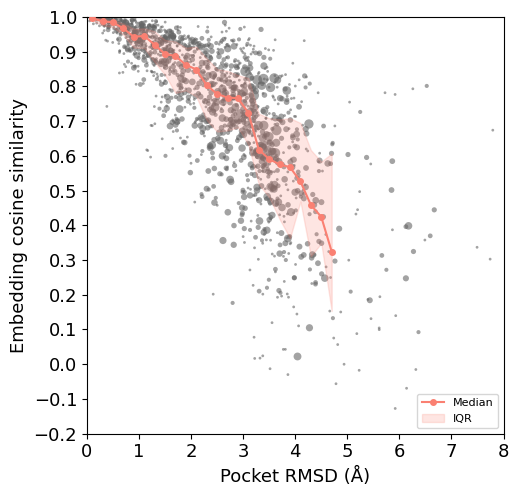

wrote /Users/jsutges/Documents/NATURAL_LIGANDS/RESULTS/pocket_struct_compare/unique_pair_viz/fig_per_ligand_summary_scatter_wellaligned.png


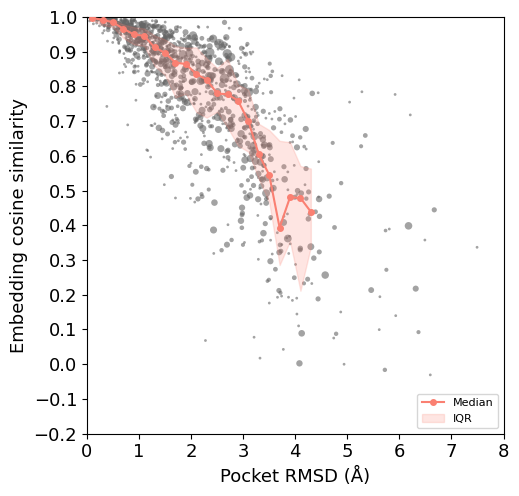

In [60]:
ERRORBAR_AXES = 'none'   # 'y', 'x', 'both', or 'none'
N_BINS_LIGAND = 40
MIN_BIN_COUNT = 9   # bins under this are merged with a neighbour, or blanked
MERGE_SPARSE_BINS = False   # True: fold sparse bins into a neighbour;
                          # False: leave them blank (NaN) instead

LABEL_FONTSIZE = 13   # ax.set_xlabel / ax.set_ylabel
TICK_FONTSIZE = 13

def merge_sparse_bins(counts, min_count):
    """Greedily merge consecutive bins (left to right) until each
    merged group has >= min_count points. Any leftover group at the
    end that still falls short gets folded into the previous one."""
    n_bins = len(counts)
    merged_id = np.zeros(n_bins, dtype=int)
    acc, group = 0, 0
    for i in range(n_bins):
        merged_id[i] = group
        acc += counts[i]
        if acc >= min_count and i < n_bins - 1:
            group += 1
            acc = 0
    if acc < min_count and group > 0:
        merged_id[merged_id == group] = group - 1
    return merged_id

def plot_ligand_level(ax, lig, title, min_n=MIN_PAIRS_LIGAND,
                      errorbar_axes=ERRORBAR_AXES, n_bins=N_BINS_LIGAND,
                      min_bin_count=MIN_BIN_COUNT,
                      merge_sparse=MERGE_SPARSE_BINS):
    sub = lig[lig['n'] >= min_n]
    sizes = 4 + 10 * np.log10(sub['n'])
    xerr = sub['sem_rmsd'] if errorbar_axes in ('x', 'both') else None
    yerr = sub['sem_cos'] if errorbar_axes in ('y', 'both') else None
    if xerr is not None or yerr is not None:
        ax.errorbar(sub['mean_rmsd'], sub['mean_cos'], xerr=xerr, yerr=yerr,
                   fmt='none', ecolor='0.6', alpha=0.4, elinewidth=0.7,
                   zorder=1)
    ax.scatter(sub['mean_rmsd'], sub['mean_cos'], s=sizes, c='0.4',
              alpha=0.6, edgecolors='none', zorder=2)

    # Start from equal-width bins; mean_rmsd is heavily skewed low so
    # the high-RMSD tail leaves many bins with 0-2 points, where
    # median/IQR is just noise from a couple of codes. Either fold
    # each run of sparse bins into its neighbour(s) until it clears
    # min_bin_count (merge_sparse=True, the trend widens out over the
    # tail instead of vanishing), or just blank those bins out
    # (merge_sparse=False, the line stops instead of zig-zagging).
    edges = np.linspace(0, RMSD_PLOT_MAX, n_bins + 1)
    bin_idx = np.clip(np.digitize(sub['mean_rmsd'], edges) - 1,
                      0, n_bins - 1)

    if merge_sparse:
        counts = np.bincount(bin_idx, minlength=n_bins)
        merged_id = merge_sparse_bins(counts, min_bin_count)
        group_idx = merged_id[bin_idx]
        stats = sub.groupby(group_idx).agg(
            median=('mean_cos', 'median'),
            q25=('mean_cos', lambda s: s.quantile(0.25)),
            q75=('mean_cos', lambda s: s.quantile(0.75)),
            center=('mean_rmsd', 'mean'))
        stats = stats.sort_values('center')
        centers = stats['center']
    else:
        stats = sub['mean_cos'].groupby(bin_idx).agg(
            median='median', q25=lambda s: s.quantile(0.25),
            q75=lambda s: s.quantile(0.75), n='size')
        stats = stats.reindex(range(n_bins))
        stats.loc[stats['n'] < min_bin_count,
                 ['median', 'q25', 'q75']] = np.nan
        centers = (edges[:-1] + edges[1:]) / 2

    ax.plot(centers, stats['median'], color='salmon', marker='o', ms=4,
           label='Median', zorder=4)
    ax.fill_between(centers, stats['q25'], stats['q75'], color='salmon',
                    alpha=0.2, label='IQR', zorder=3)

    fit = linregress(sub['mean_rmsd'], sub['mean_cos'])
    # xs = np.array([0, RMSD_PLOT_MAX])
    # ax.plot(xs, fit.slope * xs + fit.intercept, color='#c44e52', lw=2,
    #        zorder=3)

    rho = spearmanr(sub['mean_rmsd'], sub['mean_cos']).statistic
    #ax.set_title(f'{title}\n{len(sub):,} codes (>= {min_n} pairs), '
                #f'rho={rho:.2f}, linear r={fit.rvalue:.2f}',
                #fontsize=TITLE_FONTSIZE)
    ax.set_xlabel('Pocket RMSD (Å)', fontsize=LABEL_FONTSIZE)
    #ax.set_xlim(0, RMSD_PLOT_MAX); ax.set_ylim(-0.2, 1.0)
    ax.set_xlim(0, 8);
    ax.set_xticks(np.arange(0,9,1))
    ax.set_yticks(np.arange(-0.2,1.1,0.1))
    ax.set_ylim(-0.2, 1.0)
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    ax.legend(fontsize=8, loc='lower right')

for lig, label, suffix in [(lig_all, 'all pairs', 'all'),
                          (lig_well, 'well-aligned pairs', 'wellaligned')]:
    fig, ax = plt.subplots(figsize=(6, 5.5), dpi = 100)
    plot_ligand_level(ax, lig, label)
    ax.set_ylabel('Embedding cosine similarity', fontsize=LABEL_FONTSIZE)
    #fig.suptitle('Per-ligand summary - one point per ligand code, equal '
                #'weight (marker size ~ log10 pairs)', fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    out = OUT_DIR / f'fig_per_ligand_summary_scatter_{suffix}.png'
    fig.savefig(out, dpi=900, bbox_inches='tight')
    print('wrote', out)
    plt.show()

## Same-protein (UniProt) contamination check

Two structures in a pair can be near-duplicates of the *same* protein
(different crystallizations, mutants, apo/holo pairs) rather than
genuinely different proteins converging on the same ligand. Notebook
21 now tags every pair with `same_uniprot` (exact match via the
cached PDB->UniProt mapping) - split the correlation by that flag.

In [9]:
known = P['same_uniprot'].notna()
print(f'pairs with known UniProt on both sides: {int(known.sum()):,} '
     f'({known.mean() * 100:.1f}%)')
print(f'  same protein:      {int((P["same_uniprot"] == True).sum()):,}')
print(f'  different protein: {int((P["same_uniprot"] == False).sum()):,}')

wdf_known = wdf[wdf['same_uniprot'].notna()]
same_w = wdf_known[wdf_known['same_uniprot'] == True]
diff_w = wdf_known[wdf_known['same_uniprot'] == False]
print(f'\nwell-aligned subset: {len(wdf):,} pairs, '
     f'{len(same_w):,} same-protein ({len(same_w) / len(wdf) * 100:.1f}%), '
     f'{len(diff_w):,} different-protein')
print()
print('Spearman rho (cos_avg vs pocket_rmsd), well-aligned subset:')
print('  all:              ',
     round(spearmanr(wdf['pocket_rmsd'], wdf['cos_avg']).statistic, 3))
print('  same UniProt only:',
     round(spearmanr(same_w['pocket_rmsd'], same_w['cos_avg']).statistic, 3))
print('  diff UniProt only:',
     round(spearmanr(diff_w['pocket_rmsd'], diff_w['cos_avg']).statistic, 3))

pairs with known UniProt on both sides: 697,105 (97.3%)
  same protein:      17,986
  different protein: 679,119

well-aligned subset: 147,791 pairs, 15,002 same-protein (10.2%), 129,961 different-protein

Spearman rho (cos_avg vs pocket_rmsd), well-aligned subset:
  all:               -0.558
  same UniProt only: -0.686
  diff UniProt only: -0.52


## Sequence-identity exclusion ladder (pooled)

A continuous, finer-grained version of the same-protein check:
`seq_identity` (notebook 21, max %identity over every pocket-forming
chain pair, via `mmseqs easy-search`) lets us progressively exclude
pairs at or above a shrinking identity threshold and watch whether
the pooled correlation survives - not just a same/different-protein
binary, but 100% down to 30% identity in steps.

wrote /Users/jsutges/Documents/NATURAL_LIGANDS/RESULTS/pocket_struct_compare/unique_pair_viz/fig_si_ladder_trend.png


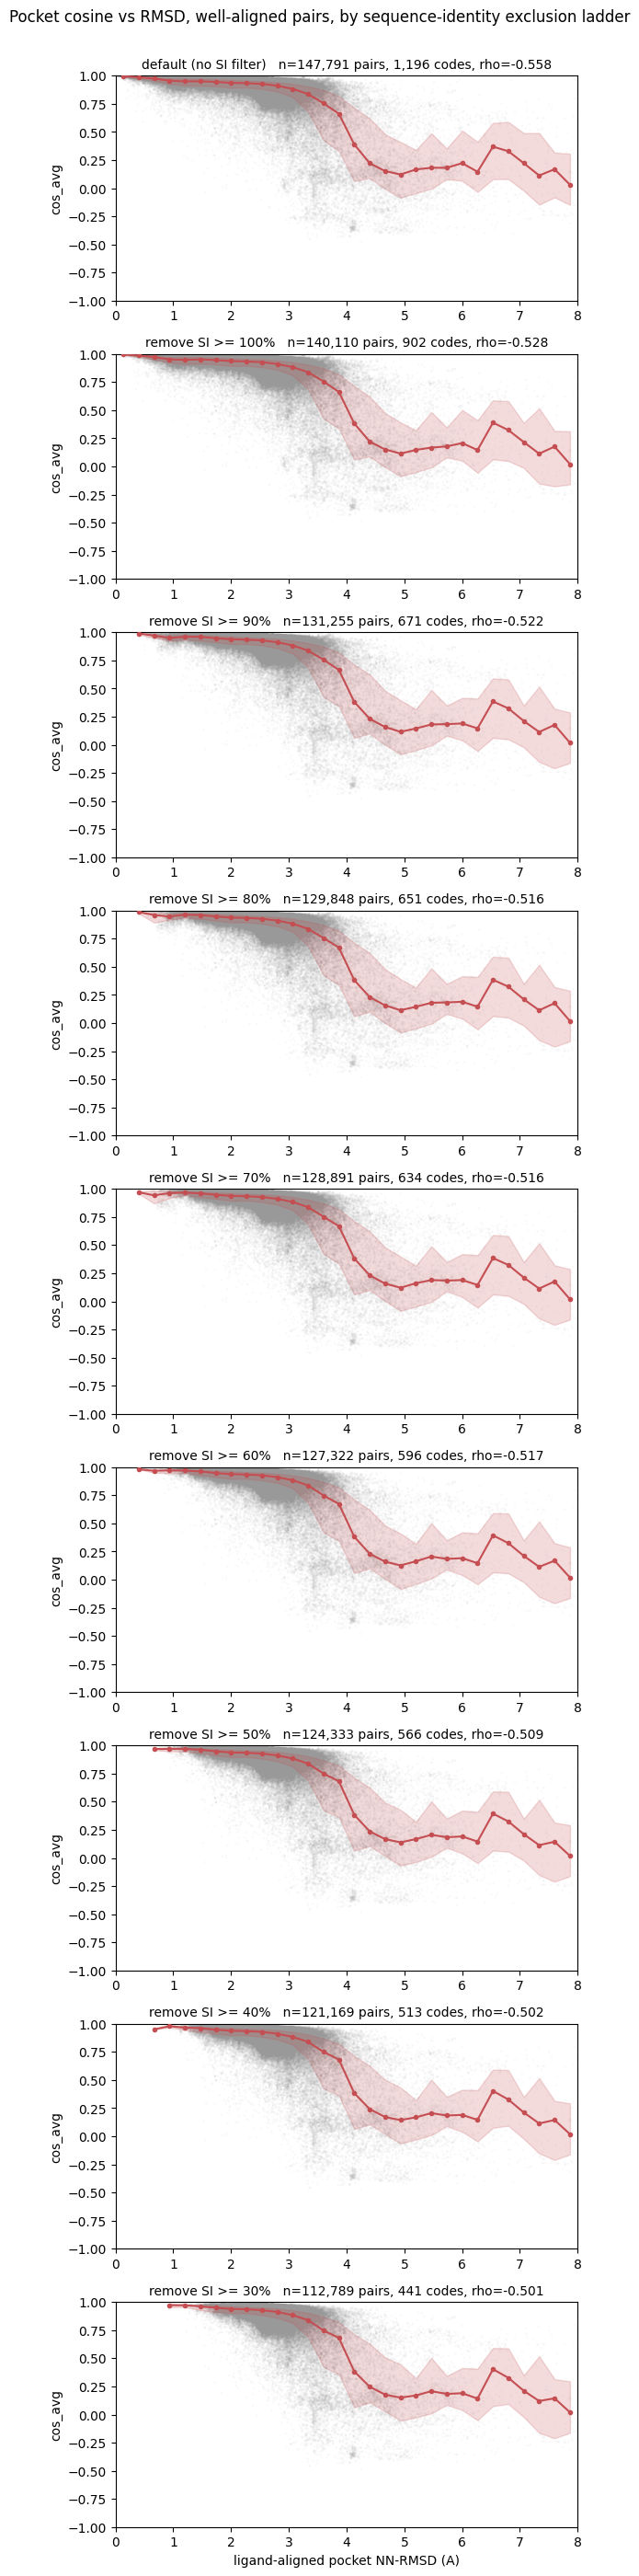

                 level  threshold  n_pairs  n_codes  spearman
default (no SI filter)        NaN   147791     1196    -0.558
     remove SI >= 100%        1.0   140110      902    -0.528
      remove SI >= 90%        0.9   131255      671    -0.522
      remove SI >= 80%        0.8   129848      651    -0.516
      remove SI >= 70%        0.7   128891      634    -0.516
      remove SI >= 60%        0.6   127322      596    -0.517
      remove SI >= 50%        0.5   124333      566    -0.509
      remove SI >= 40%        0.4   121169      513    -0.502
      remove SI >= 30%        0.3   112789      441    -0.501


In [52]:
SI_THRESHOLDS = [1.00, 0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30]
si_levels = [('default (no SI filter)', None)]
si_levels += [(f'remove SI >= {int(t * 100)}%', t) for t in SI_THRESHOLDS]

# These stacked SI-ladder panels use their own (smaller) title size to
# fit many rows, plus their own suptitle size - both kept local to this
# cell since they already differed from the general TITLE_FONTSIZE above.
SI_TITLE_FONTSIZE = 10
SUPTITLE_FONTSIZE = 12
TICK_FONTSIZE = 10 

def trend_stats(df, n_bins=30, rmsd_max=RMSD_PLOT_MAX):
    edges = np.linspace(0, rmsd_max, n_bins + 1)
    bin_idx = np.clip(np.digitize(df['pocket_rmsd'], edges) - 1,
                      0, n_bins - 1)
    stats = df['cos_avg'].groupby(bin_idx).agg(
        median='median', q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75))
    stats = stats.reindex(range(n_bins))
    centers = (edges[:-1] + edges[1:]) / 2
    return centers, stats

fig, axes = plt.subplots(len(si_levels), 1, figsize=(6, 3.1 * len(si_levels)))
si_rows = []
for ax, (label, thr) in zip(axes, si_levels):
    sub = wdf if thr is None else wdf[wdf['seq_identity'] < thr]
    n_codes = sub['code'].nunique()
    rho = (spearmanr(sub['pocket_rmsd'], sub['cos_avg']).statistic
          if len(sub) > 10 else np.nan)
    si_rows.append({'level': label, 'threshold': thr, 'n_pairs': len(sub),
                    'n_codes': n_codes, 'spearman': rho})
    centers, stats = trend_stats(sub)
    ax.scatter(sub['pocket_rmsd'], sub['cos_avg'], s=3, color='0.6',
              alpha=0.06, edgecolors='none', rasterized=True, zorder=1)
    ax.plot(centers, stats['median'], color='#c44e52', marker='o', ms=3,
           zorder=3)
    ax.fill_between(centers, stats['q25'], stats['q75'], color='#c44e52',
                    alpha=0.2, zorder=2)
    ax.set_xlim(0, RMSD_PLOT_MAX); ax.set_ylim(-1, 1)
    ax.set_ylabel('cos_avg', fontsize=LABEL_FONTSIZE)
    ax.set_title(f'{label}   n={len(sub):,} pairs, {n_codes:,} codes, '
                f'rho={rho:.3f}', fontsize=SI_TITLE_FONTSIZE)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
axes[-1].set_xlabel('ligand-aligned pocket NN-RMSD (A)', fontsize=LABEL_FONTSIZE)
fig.suptitle('Pocket cosine vs RMSD, well-aligned pairs, by '
            'sequence-identity exclusion ladder', fontsize=SUPTITLE_FONTSIZE,
            y=1.002)
fig.tight_layout()
out = OUT_DIR / 'fig_si_ladder_trend.png'
fig.savefig(out, dpi=130, bbox_inches='tight')
print('wrote', out)
plt.show()

si_summary = pd.DataFrame(si_rows)
si_summary.to_csv(OUT_DIR / 'si_ladder_summary.tsv', sep='\t', index=False)
print(si_summary.round(3).to_string(index=False))

## Sequence-identity exclusion ladder (per-ligand, equal-weighted)

The pooled ladder above only tests whether the *frequency-weighted*
correlation survives excluding close homologs. The per-ligand
equal-weighted view (previous section) was substantially stronger
than pooled (rho ~ -0.83 vs -0.56) - repeat the same exclusion ladder
on *that* view to check whether the extra strength is itself partly a
same-protein-redundancy artefact.

In [ ]:
def ligand_summary_si(df, min_n=MIN_PAIRS_LIGAND):
    g = df.groupby('code').agg(n=('cos_avg', 'size'),
                               mean_cos=('cos_avg', 'mean'),
                               mean_rmsd=('pocket_rmsd', 'mean'))
    return g[g['n'] >= min_n]

fig, axes = plt.subplots(len(si_levels), 1, figsize=(6, 3.1 * len(si_levels)))
si_lig_rows = []
for ax, (label, thr) in zip(axes, si_levels):
    sub_pairs = wdf if thr is None else wdf[wdf['seq_identity'] < thr]
    lig = ligand_summary_si(sub_pairs)
    rho = (spearmanr(lig['mean_rmsd'], lig['mean_cos']).statistic
          if len(lig) > 10 else np.nan)
    si_lig_rows.append({'level': label, 'threshold': thr,
                        'n_pairs': len(sub_pairs), 'n_codes': len(lig),
                        'spearman': rho})
    sizes = 4 + 10 * np.log10(lig['n'])
    ax.scatter(lig['mean_rmsd'], lig['mean_cos'], s=sizes, c='0.35',
              alpha=0.6, edgecolors='none', zorder=2)
    if len(lig) > 2:
        fit = linregress(lig['mean_rmsd'], lig['mean_cos'])
        xs = np.array([0, RMSD_PLOT_MAX])
        ax.plot(xs, fit.slope * xs + fit.intercept, color='#c44e52', lw=2,
               zorder=3)
    ax.set_xlim(0, RMSD_PLOT_MAX); ax.set_ylim(-0.2, 1.0)
    ax.set_ylabel('mean cos_avg\nper ligand', fontsize=LABEL_FONTSIZE)
    ax.set_title(f'{label}   {len(lig):,} codes ({len(sub_pairs):,} pairs), '
                f'rho={rho:.3f}', fontsize=SI_TITLE_FONTSIZE)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
axes[-1].set_xlabel('mean pocket NN-RMSD per ligand (A)', fontsize=LABEL_FONTSIZE)
fig.suptitle('Per-ligand equal-weighted: mean cosine vs mean RMSD, by '
            'sequence-identity exclusion ladder', fontsize=SUPTITLE_FONTSIZE,
            y=1.002)
fig.tight_layout()
out = OUT_DIR / 'fig_si_ladder_perligand_trend.png'
fig.savefig(out, dpi=130, bbox_inches='tight')
print('wrote', out)
plt.show()

si_lig_summary = pd.DataFrame(si_lig_rows)
si_lig_summary.to_csv(OUT_DIR / 'si_ladder_perligand_summary.tsv', sep='\t',
                      index=False)
print(si_lig_summary.round(3).to_string(index=False))

In [ ]:
CAT_TICK_FONTSIZE = 8  # rotated SI-level tick labels, this figure only

fig, ax = plt.subplots(figsize=(7, 5))
x = list(range(len(si_levels)))
ax.plot(x, si_summary['spearman'], marker='o', color='#4c72b0',
       label='pooled (frequency-weighted)')
ax.plot(x, si_lig_summary['spearman'], marker='s', color='#c44e52',
       label='per-ligand (equal-weighted)')
ax.set_xticks(x)
ax.set_xticklabels([lv[0].replace('remove SI >= ', '<') for lv in si_levels],
                   rotation=40, ha='right', fontsize=CAT_TICK_FONTSIZE)
ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)
ax.set_ylabel('Spearman rho (cos_avg vs pocket_rmsd)', fontsize=LABEL_FONTSIZE)
ax.axhline(0, color='k', lw=0.6)
ax.legend(fontsize=9)
ax.set_title('Pooled vs per-ligand correlation, across the SI exclusion ladder',
            fontsize=TITLE_FONTSIZE)
fig.tight_layout()
out = OUT_DIR / 'fig_si_ladder_pooled_vs_perligand.png'
fig.savefig(out, dpi=130, bbox_inches='tight')
print('wrote', out)
plt.show()

## Takeaways

- With notebook 21's dedup now consistent with notebook 24's
  (cross-dataset `(pdb_id, lig_resname)` only, not one-structure-
  per-PDB), the pair table has **716,099 same-ligand pocket pairs**
  across **1,479 ligand codes** - 47.2% more pairs and 21.9% more
  codes than the prior (over-deduped) version - of which **147,791
  (20.6%)** pass the well-aligned filter (`lig_align_rmsd <= 1.0` A)
  that makes the pocket RMSD meaningful.
- Pairs per ligand are extremely skewed: median is **3 pairs/code**,
  **709 of 1,479 codes (47.9%) contribute exactly 1 pair**, while
  **just 10 codes (NAD, FAD, ADP, ...) account for 88.6% of all
  pairs** (NAD, FAD and ADP alone are 61.3%). Any statistic on raw
  pooled pairs is mostly a statistic about a handful of cofactors.
- All three visualisation styles agree on the direction (negative
  correlation, cosine falls as RMSD rises) and on the well-aligned
  filter mattering, but they emphasise different things: hexbin
  shows where the *density* sits, scatter shows which points come
  from the oversampled cofactors (large markers) vs the long tail of
  rarely-seen ligands (small markers), and the binned median + IQR
  trend is the cleanest single read of the aggregate relationship,
  same as it was for Tanimoto in notebook 24.
- **The pooled and ligand-equal-weighted views disagree, and the gap
  is the headline result.** Raw pooled Spearman (well-aligned,
  `cos_avg`) is **rho = -0.558**; re-weighted so every ligand code
  counts once (mean RMSD vs mean cosine per code) it is **rho ~ -0.74
  to -0.85** for minimum-pairs thresholds from 1 to 20, only softening
  to -0.62/-0.74 at a 50-pair minimum where just ~100-150 codes
  remain. The dominant cofactors individually show a *weaker*
  cosine-RMSD relationship than the long tail of less-common ligands
  does, so pooling by raw pair count understates how strong and
  general the relationship actually is.
- Practical read: use the **raw pooled view** if the question is
  'what does a typical *comparison* look like' (which is inherently
  cofactor-heavy, since that's what the data actually contains), and
  the **per-ligand summary view** if the question is 'does this
  relationship hold across ligands generally' - they are both
  correct, they just answer different questions.
- **Same-protein pairs are rare overall (2.5%) but concentrated in the
  well-aligned subset (10.2%)**, since two structures of the *same*
  protein reproduce the same binding pose almost by construction -
  exactly the pairs the well-aligned filter selects for. They also
  correlate more strongly (rho = -0.686) than genuinely different
  proteins (rho = -0.52), so they inflate the pooled well-aligned
  number (-0.558) above the cross-protein-only signal.
- **The sequence-identity ladder confirms this is a real but modest
  effect for the pooled view, and a larger one for the per-ligand
  view.** Progressively excluding pairs at or above 100% down to 30%
  sequence identity moves pooled rho only from -0.558 to -0.501 (~10%
  relative) - the pooled correlation mostly survives even among
  clearly unrelated proteins. The per-ligand equal-weighted rho moves
  much more, from -0.834 to -0.644 (~23% relative): a meaningful share
  of what made the per-ligand view look so much stronger than pooled
  was individual ligand codes whose few pairs happened to be close or
  identical proteins. The honest per-ligand number for 'does this
  generalise across genuinely different proteins' is closer to -0.64
  to -0.73 (the <30% to <70% SI range) than the headline -0.83.